# LDV Linearity Analysis

Investigates whether **coupling efficiency η depends on vibration amplitude**
using a dedicated mono-frequency linearity test signal:
8 frequencies (5-400 Hz), each applied for 3.5 s with a linearly increasing
amplitude ramp (0->1) followed by a 0.5 s fade.

| Section | Content |
|---|---|
| 0 | Imports & dataset selection |
| 1 | Load datasets |
| 2 | Static geometry |
| 3 | Raw signal overview |
| 4 | Run linearity analysis |
| 5 | eta(t) per frequency |
| 6 | eta vs amplitude -- linearity check |
| 7 | Cross-cable comparison |
| 8 | Interactive QC dashboard |


---
## Section 0  Imports & dataset selection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, signal, geometry, analysis, plotting, widgets

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.0,
})

# All four linearity test datasets (edit to restrict to a subset)
ACTIVE_LABELS = config.LINEARITY_LABELS
DATASETS = config.select_datasets(ACTIVE_LABELS)

print(f'Linearity frequencies: {config.LIN_FREQUENCIES} Hz')
print(f'Segment: {config.LIN_SEGMENT_DURATION} s'
      f'  (ramp {config.LIN_SEGMENT_DURATION - config.LIN_FADE_DURATION} s'
      f'  + fade {config.LIN_FADE_DURATION} s)')
print()
for f in config.LIN_FREQUENCIES:
    t0, t1 = config.linearity_segment_window(f)
    print(f'  {f:4.0f} Hz  ->  [{t0:.1f}, {t1:.1f}] s')


Linearity frequencies: [5, 20, 50, 100, 150, 200, 300, 400] Hz
Segment: 3.5 s  (ramp 3.0 s  + fade 0.5 s)

     5 Hz  ->  [1.0, 4.5] s
    20 Hz  ->  [5.5, 9.0] s
    50 Hz  ->  [10.0, 13.5] s
   100 Hz  ->  [14.5, 18.0] s
   150 Hz  ->  [19.0, 22.5] s
   200 Hz  ->  [23.5, 27.0] s
   300 Hz  ->  [28.0, 31.5] s
   400 Hz  ->  [32.5, 36.0] s


---
## Section 1  Load datasets

In [2]:
for cfg in DATASETS:
    io.load_cable_dataset(cfg)
    print(f"  {cfg['label']:30s}  n_sensors={cfg['n_sensors']:2d}"
          f"  fs={cfg['fs']:.0f} Hz  duration={cfg['t'][-1]:.2f} s")


  [LinTest_Cable5_5cm] removing 6 dead sensor(s).
  [LinTest_Cable5_5cm] shaker active channel: idx=9 (of 10 channels; 1 non-zero)
  LinTest_Cable5_5cm              n_sensors= 3  fs=5000 Hz  duration=38.00 s
  [LinTest_Cable6_5cm] removing 6 dead sensor(s).
  [LinTest_Cable6_5cm] shaker active channel: idx=9 (of 10 channels; 1 non-zero)
  LinTest_Cable6_5cm              n_sensors= 3  fs=5000 Hz  duration=38.00 s
  [LinTest_Cable7_5cm] removing 6 dead sensor(s).
  [LinTest_Cable7_5cm] shaker active channel: idx=9 (of 10 channels; 1 non-zero)
  LinTest_Cable7_5cm              n_sensors= 3  fs=5000 Hz  duration=38.00 s
  [LinTest_Cable7_10cm_Sag] shaker active channel: idx=3 (of 4 channels; 1 non-zero)
  LinTest_Cable7_10cm_Sag         n_sensors= 3  fs=5000 Hz  duration=38.00 s


---
## Section 2  Static geometry

Computes chord direction, chord length, and static sag for each dataset.
Required before running any coupling-efficiency analysis.


In [3]:
for cfg in DATASETS:
    analysis.prepare_geometry(cfg)
    print(f"  {cfg['label']:30s}  "
          f"L_chord={cfg['chord_len']*100:.2f} cm  "
          f"sag={cfg['static_sag']*1e3:.3f} mm  "
          f"eta_pred={cfg['eta_pred']:.4f}")


  LinTest_Cable5_5cm              L_chord=4.21 cm  sag=0.284 mm  eta_pred=0.9947
  LinTest_Cable6_5cm              L_chord=4.23 cm  sag=0.186 mm  eta_pred=0.9912
  LinTest_Cable7_5cm              L_chord=4.24 cm  sag=0.719 mm  eta_pred=0.4392
  LinTest_Cable7_10cm_Sag         L_chord=9.14 cm  sag=4.563 mm  eta_pred=0.0191


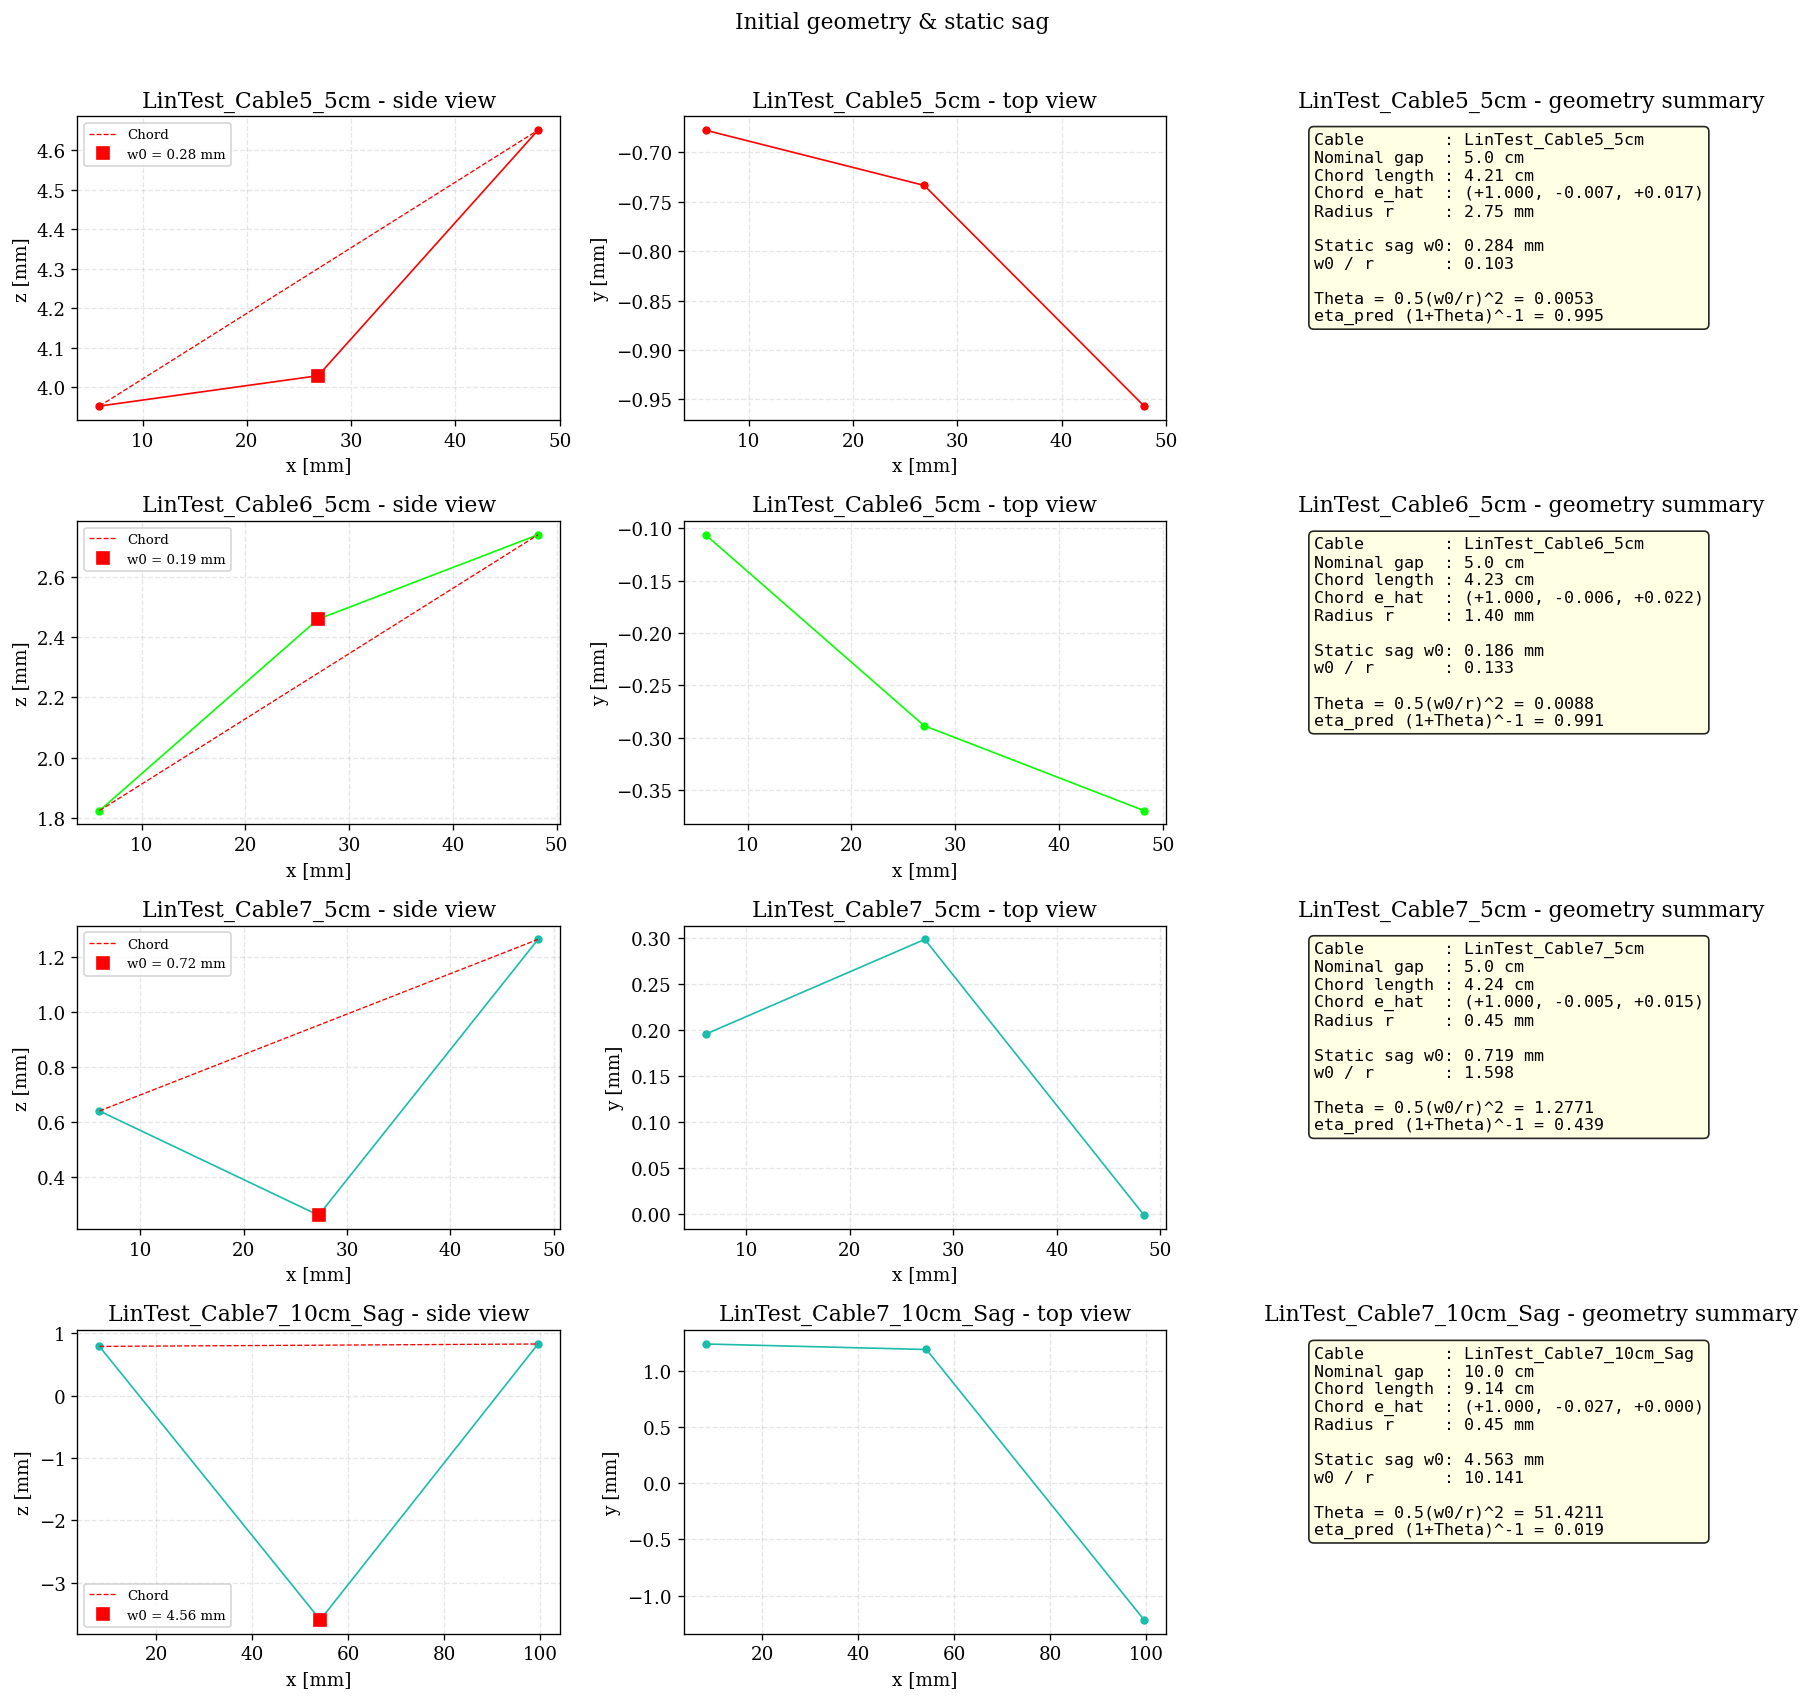

In [4]:
# Optional: XYZ geometry plot
plotting.plot_initial_geometry(DATASETS)


---
## Section 3  Raw signal overview

Full 38 s trace showing all 8 frequency segments.
The linearly increasing amplitude within each block is clearly visible.


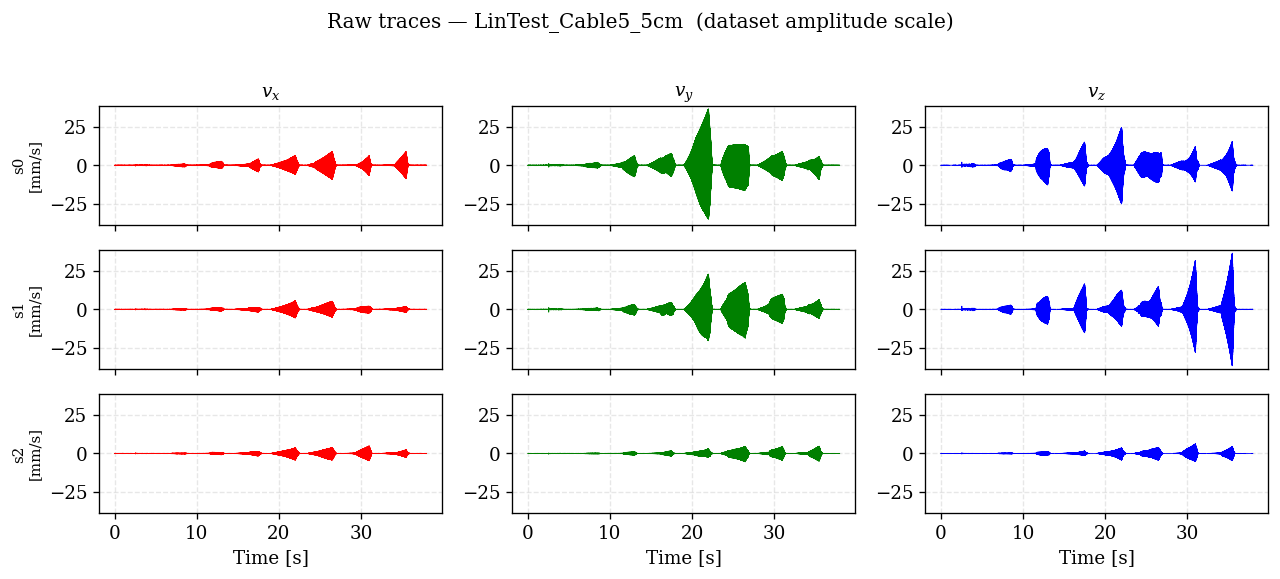

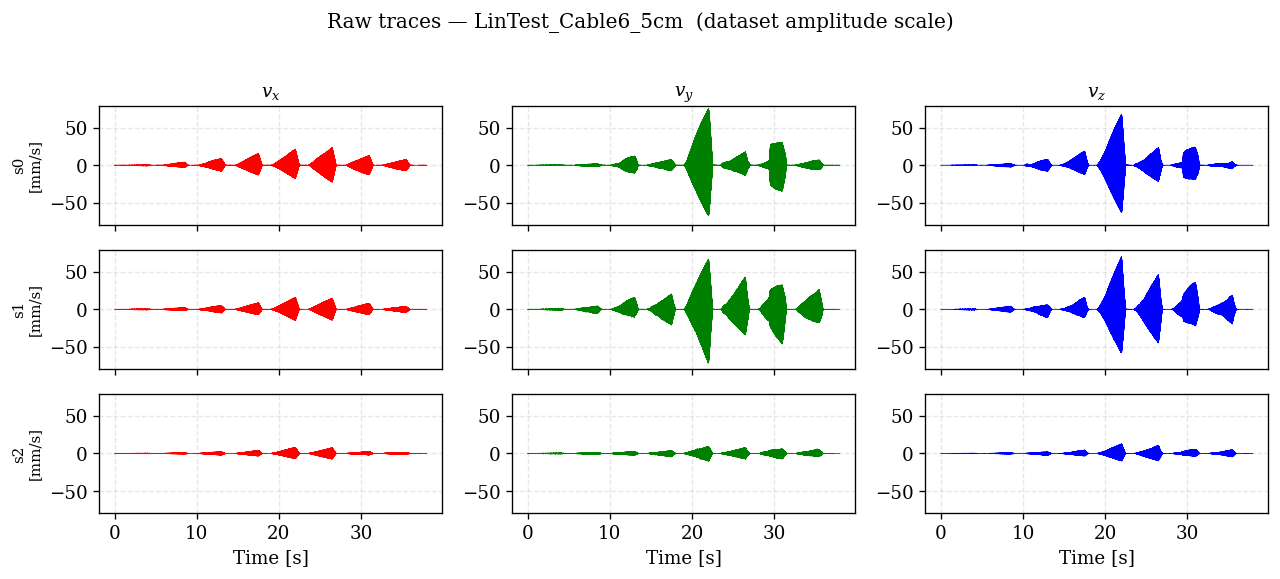

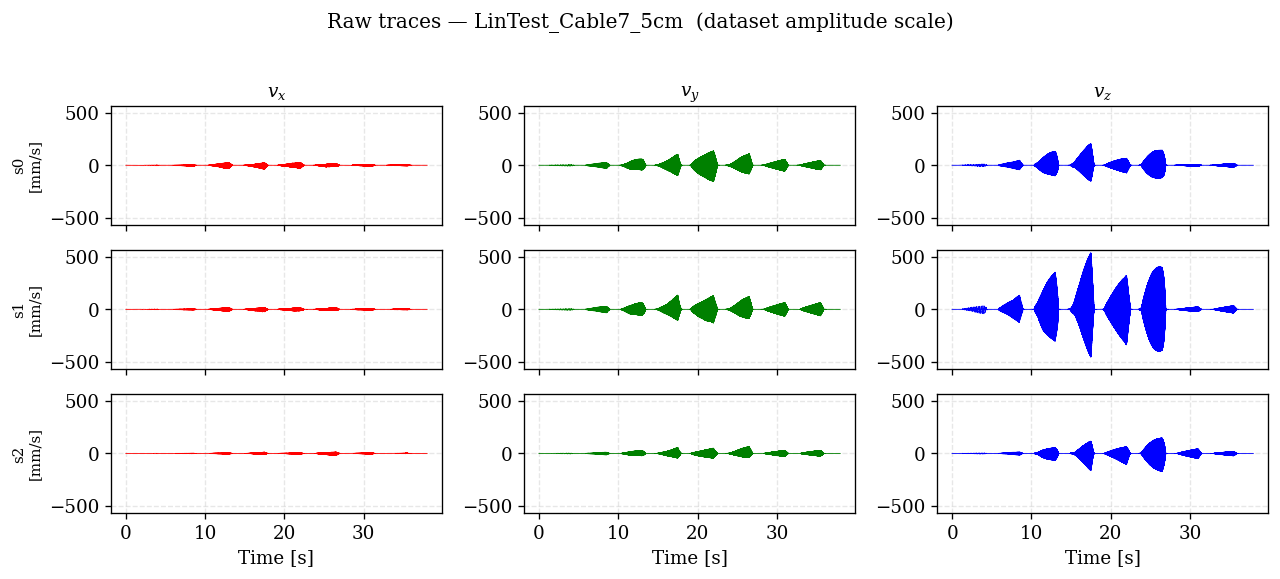

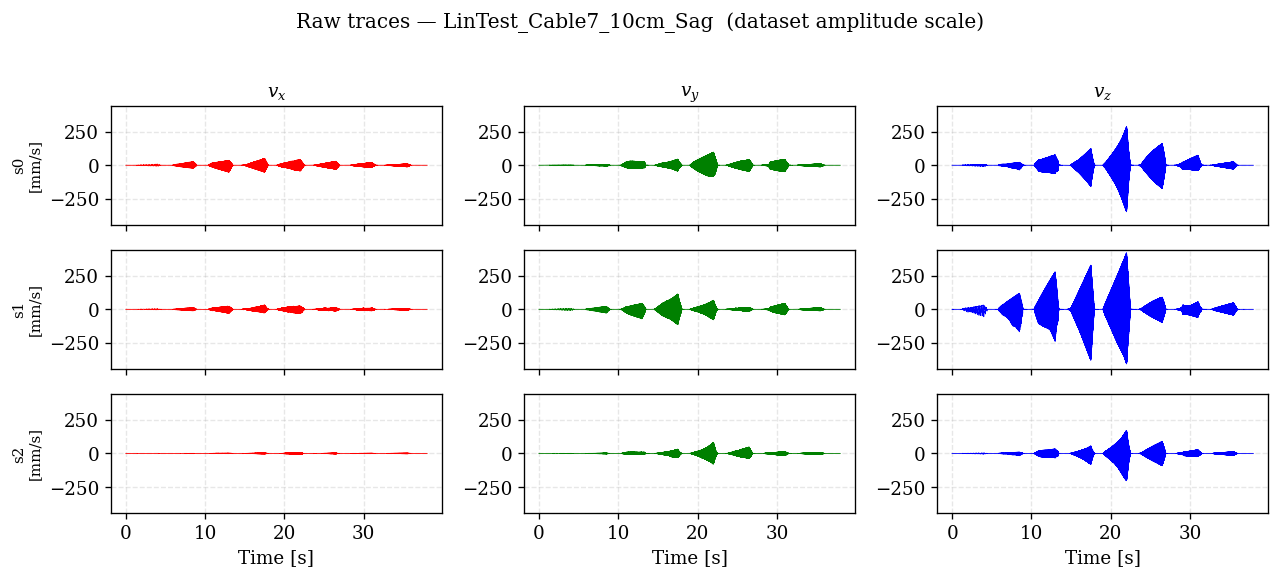

In [5]:
for cfg in DATASETS:
    plotting.plot_raw_traces_uniform(
        cfg, components=('vx', 'vy', 'vz'),
        share_scale='dataset', max_rows=4,
        title=cfg['label'],
    )


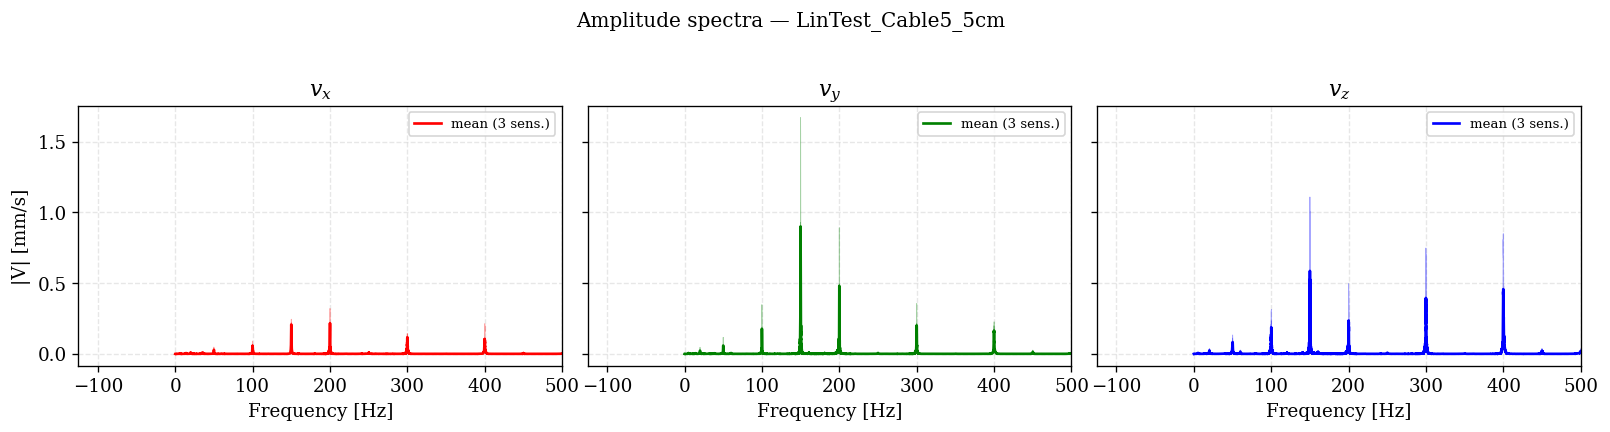

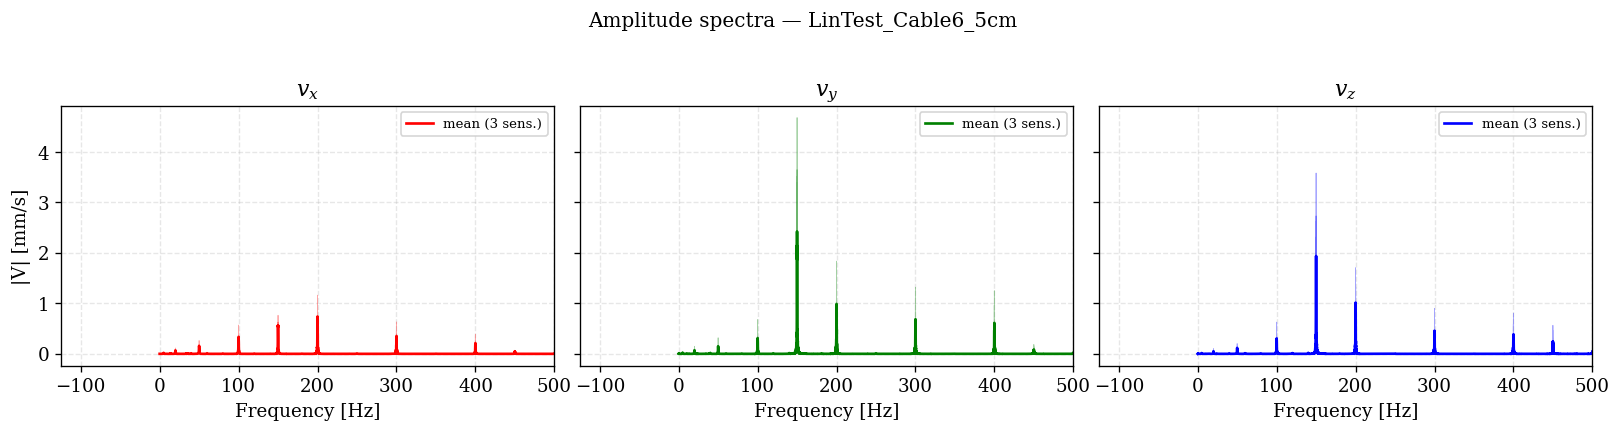

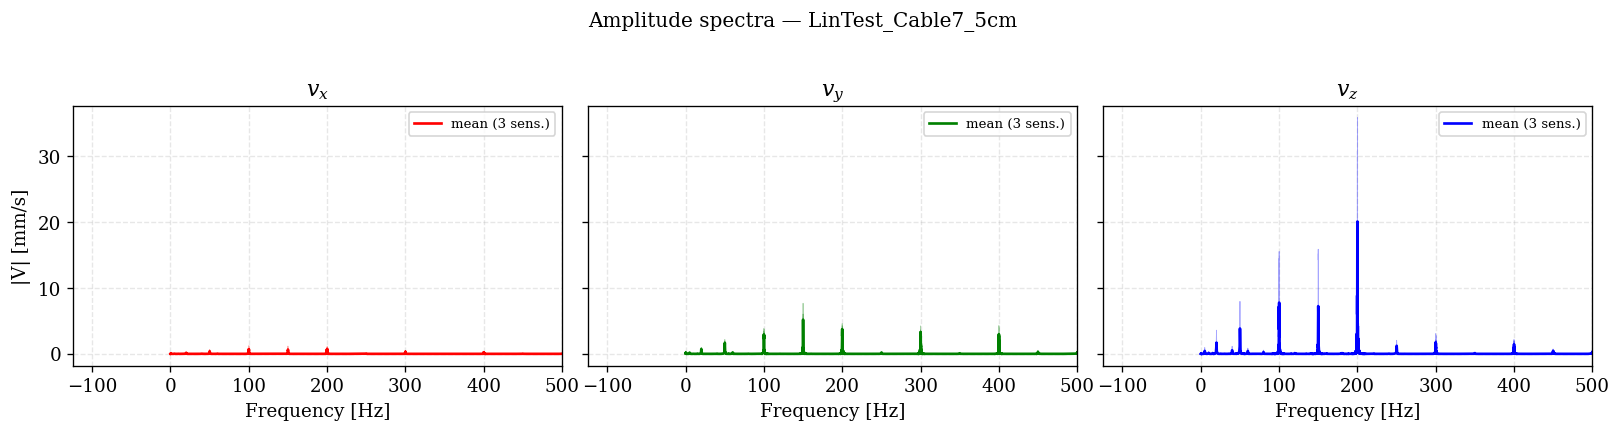

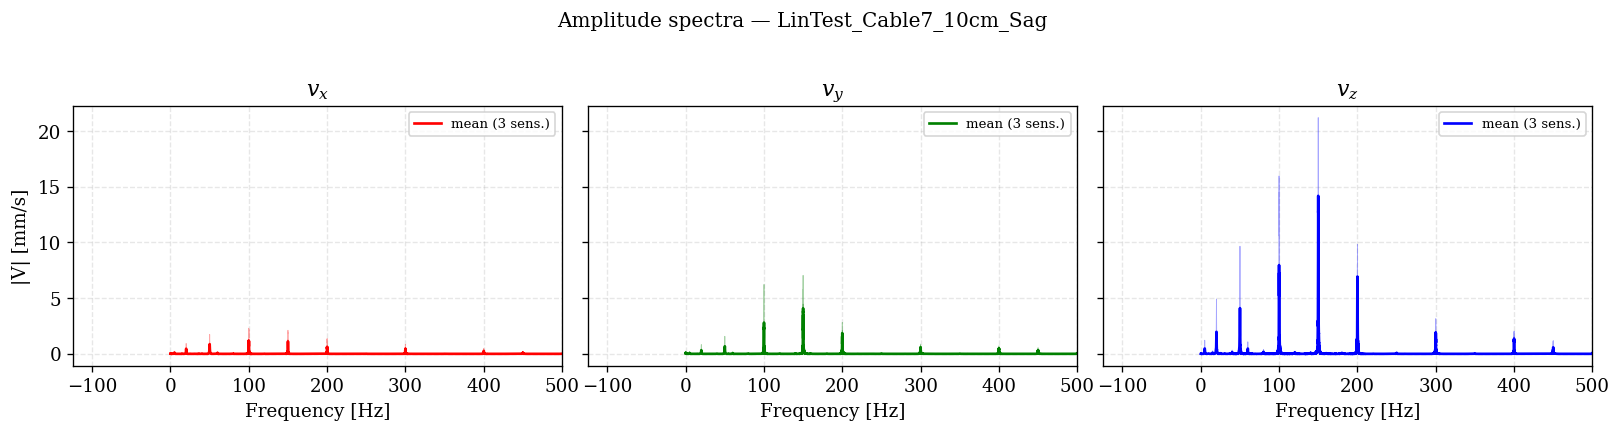

In [6]:
# Amplitude spectra of the full recording
for cfg in DATASETS:
    plotting.plot_amplitude_spectra(
        cfg, components=('vx', 'vy', 'vz'),
        f_max=500.0, xscale='linear', yscale='linear',
        overlay_sensors=True,
        title=cfg['label'],
    )


---
## Section 4  Run linearity analysis

For each frequency, `run_linearity_analysis`:
1. Extracts the full 3.5 s mono-frequency segment.
2. Bandpass-filters cable + shaker velocities around the target frequency.
3. Integrates velocity to displacement.
4. Computes cable elongation delta_xl (3-D arc-length) and shaker elongation
   delta_L (chord projection).
5. Returns eta(t) = delta_xl / delta_L over the complete segment.
6. Computes the Hilbert envelope of delta_L as the instantaneous amplitude.

Results are cached in `cfg['lin_results']` (dict keyed by frequency).


In [7]:
for cfg in DATASETS:
    print(f"\n-- {cfg['label']} --")
    analysis.run_linearity_analysis(cfg, frequencies=config.LIN_FREQUENCIES)



-- LinTest_Cable5_5cm --
     5 Hz ... η_med = 0.267
    20 Hz ... η_med = 0.256
    50 Hz ... η_med = 0.247
   100 Hz ... η_med = 0.269
   150 Hz ... η_med = 0.743
   200 Hz ... η_med = 0.358
   300 Hz ... η_med = 0.531
   400 Hz ... η_med = 0.373

-- LinTest_Cable6_5cm --
     5 Hz ... η_med = 0.465
    20 Hz ... η_med = 0.459
    50 Hz ... η_med = 0.440
   100 Hz ... η_med = 0.399
   150 Hz ... η_med = 1.287
   200 Hz ... η_med = 0.510
   300 Hz ... η_med = 0.490
   400 Hz ... η_med = 0.432

-- LinTest_Cable7_5cm --
     5 Hz ... η_med = 0.038
    20 Hz ... η_med = 0.080
    50 Hz ... η_med = 0.143
   100 Hz ... η_med = 0.097
   150 Hz ... η_med = 0.643
   200 Hz ... η_med = 0.106
   300 Hz ... η_med = 0.134
   400 Hz ... η_med = 0.090

-- LinTest_Cable7_10cm_Sag --
     5 Hz ... η_med = 0.139
    20 Hz ... η_med = 0.141
    50 Hz ... η_med = 0.126
   100 Hz ... η_med = 0.056
   150 Hz ... η_med = 0.275
   200 Hz ... η_med = 0.398
   300 Hz ... η_med = 0.204
   400 Hz ... η_med = 0

---
## Section 5  eta(t) per frequency

One column per frequency.

**Top row:** eta(t) -- bold line is running-median smoothed over 5 cycles;
thin line is raw. Grey shading = fade region. Dotted = quasi-static eta_pred.

**Bottom row:** instantaneous amplitude |delta_L| from the Hilbert envelope.


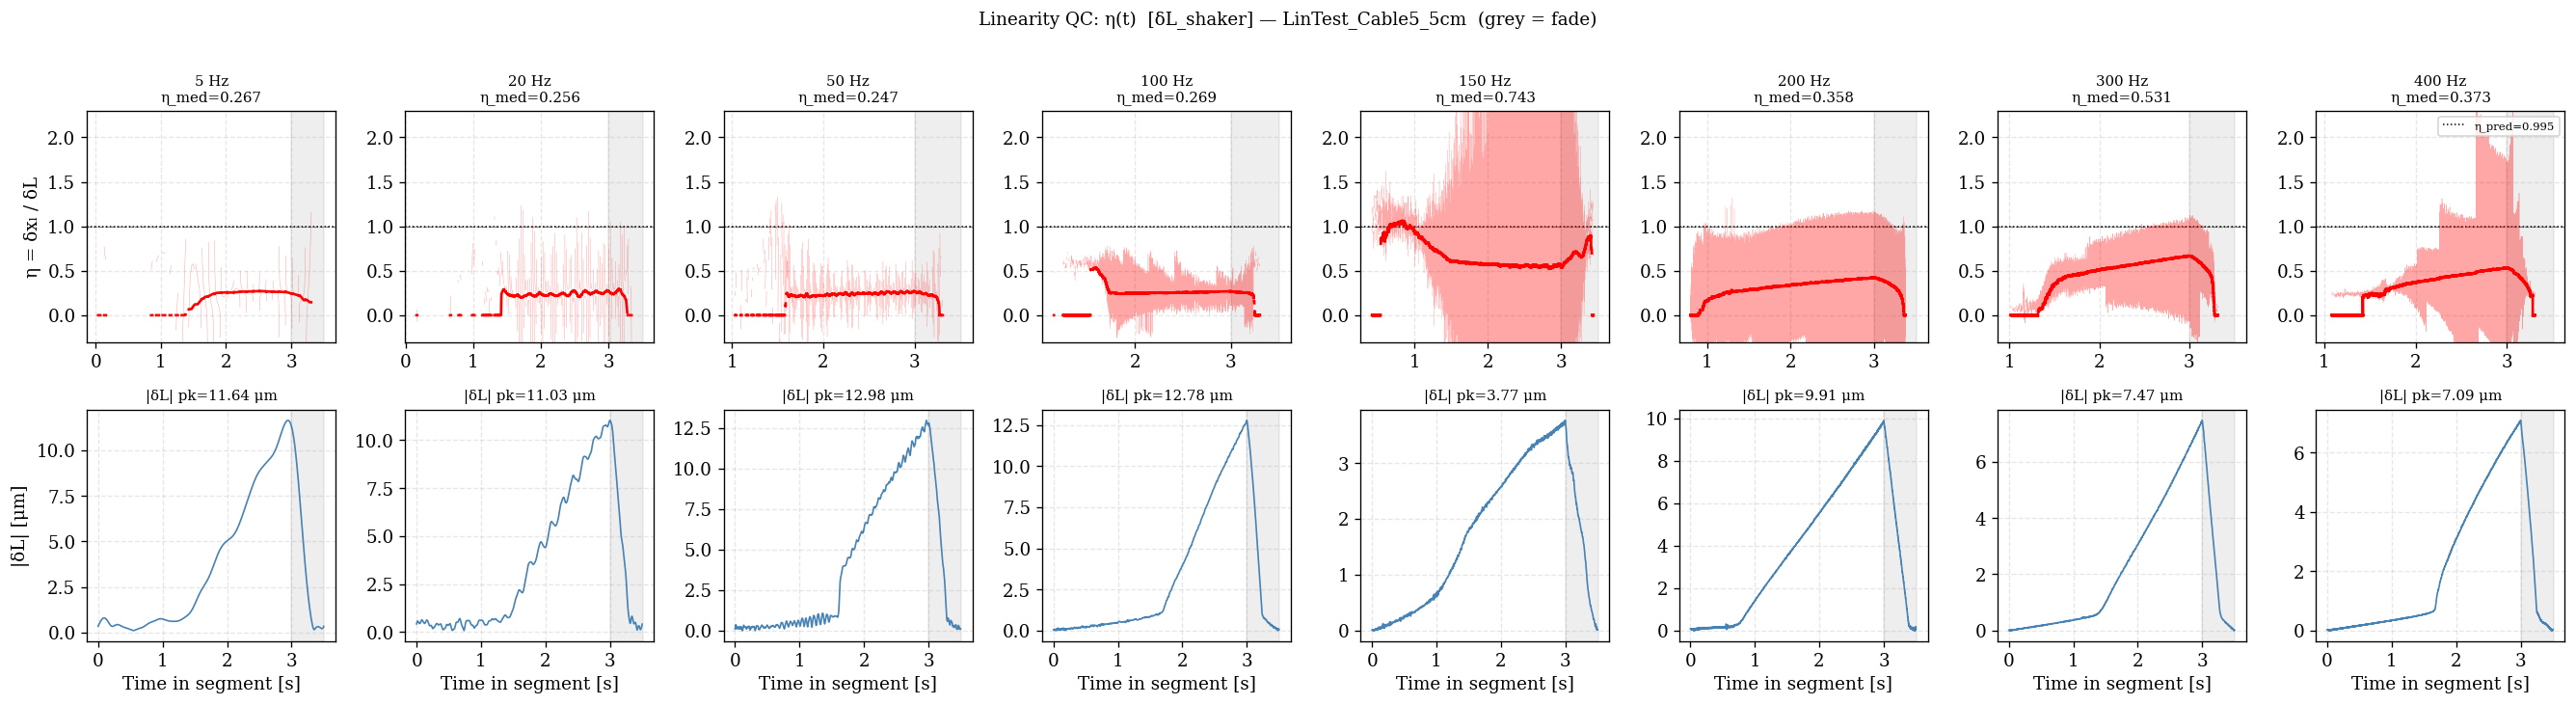

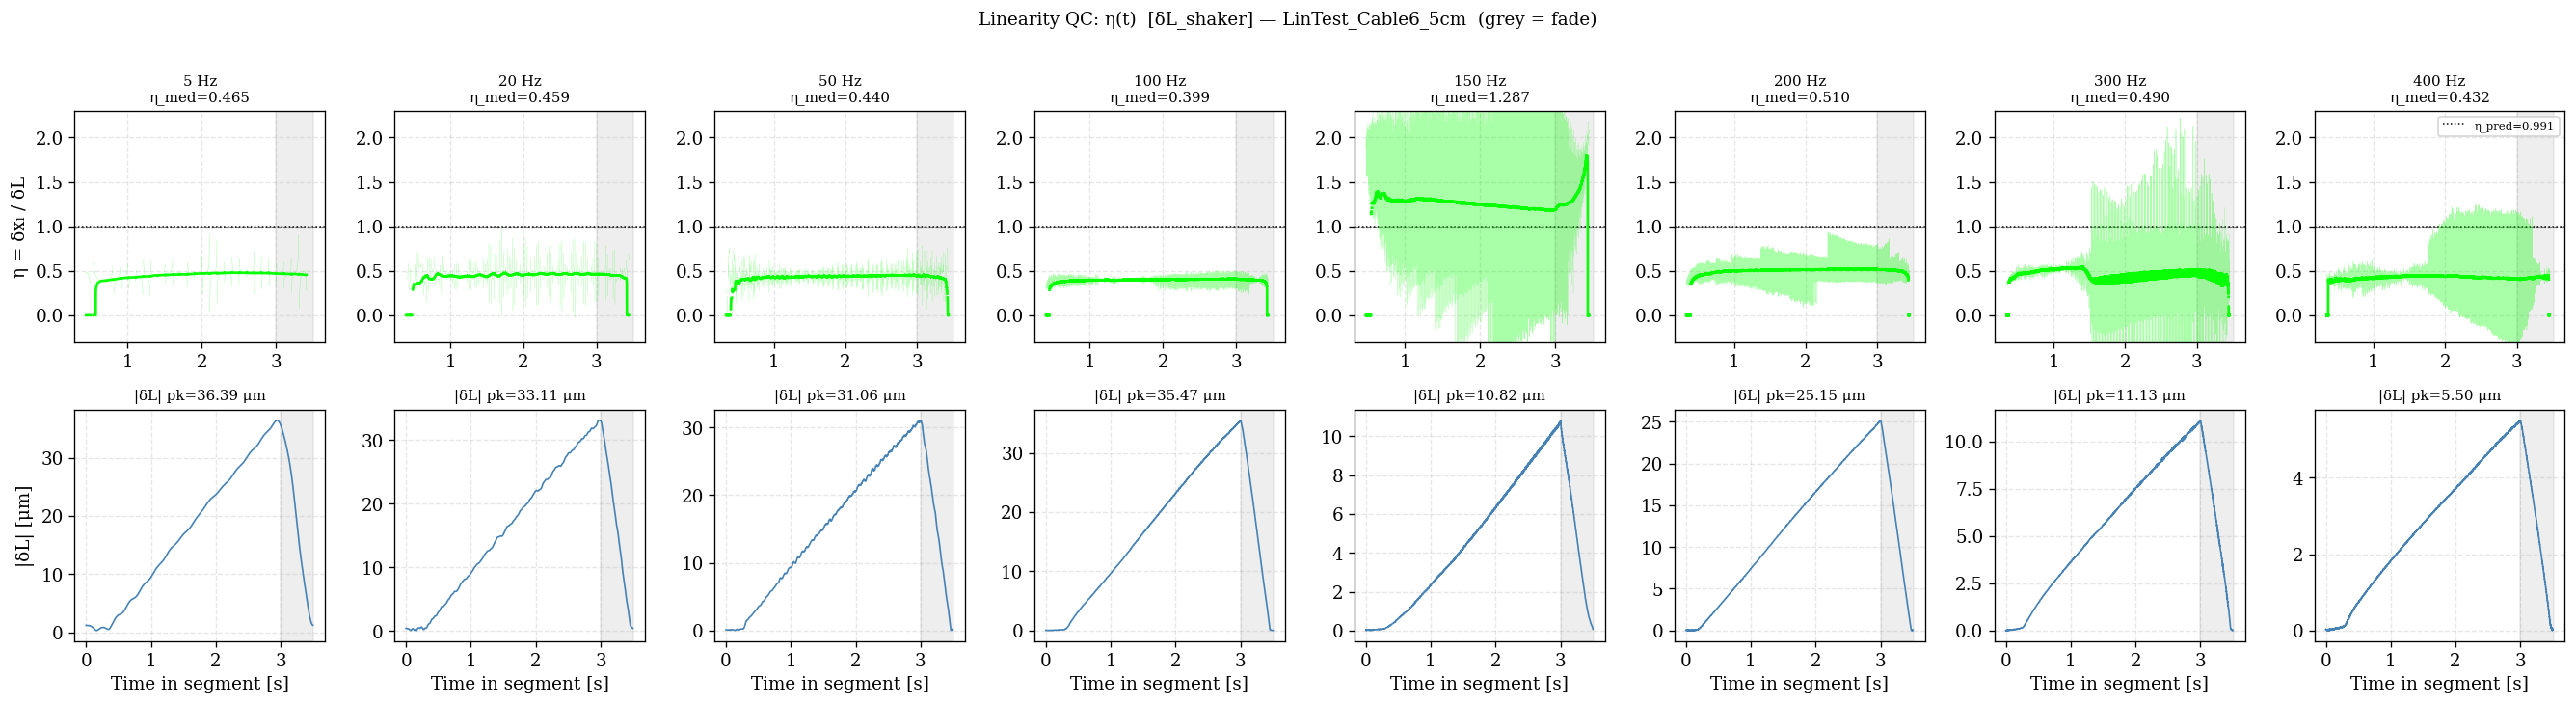

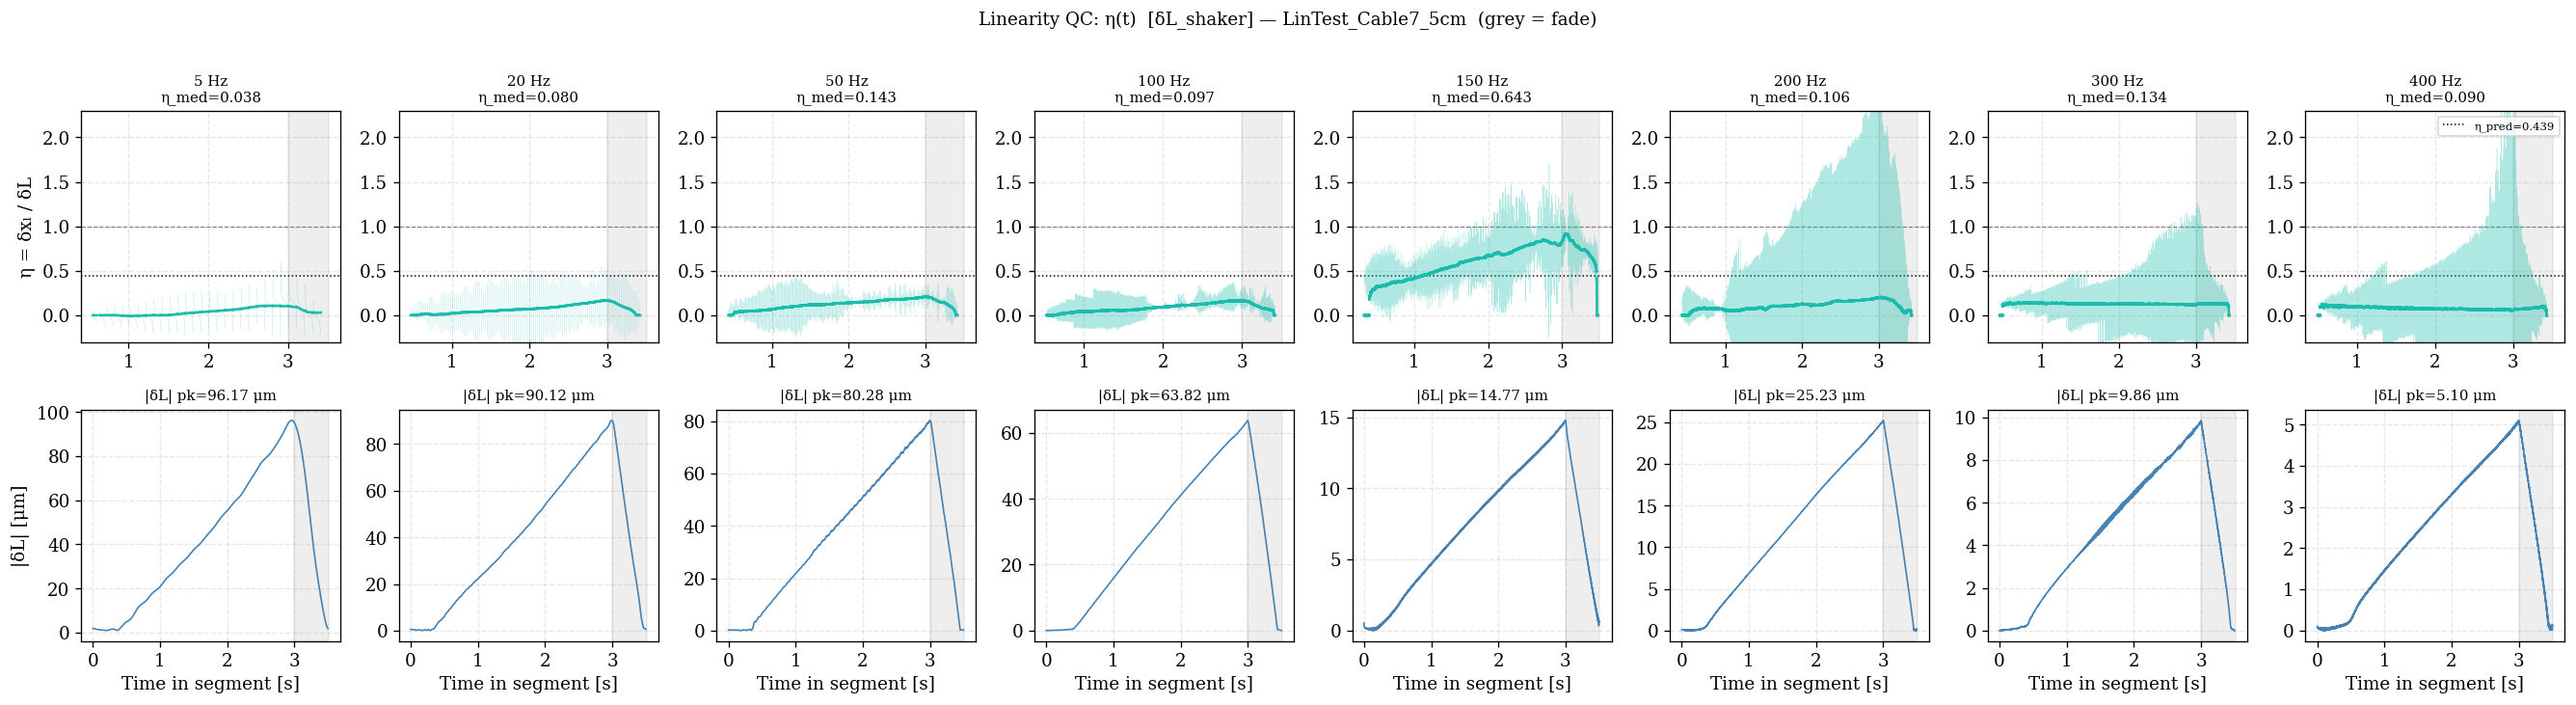

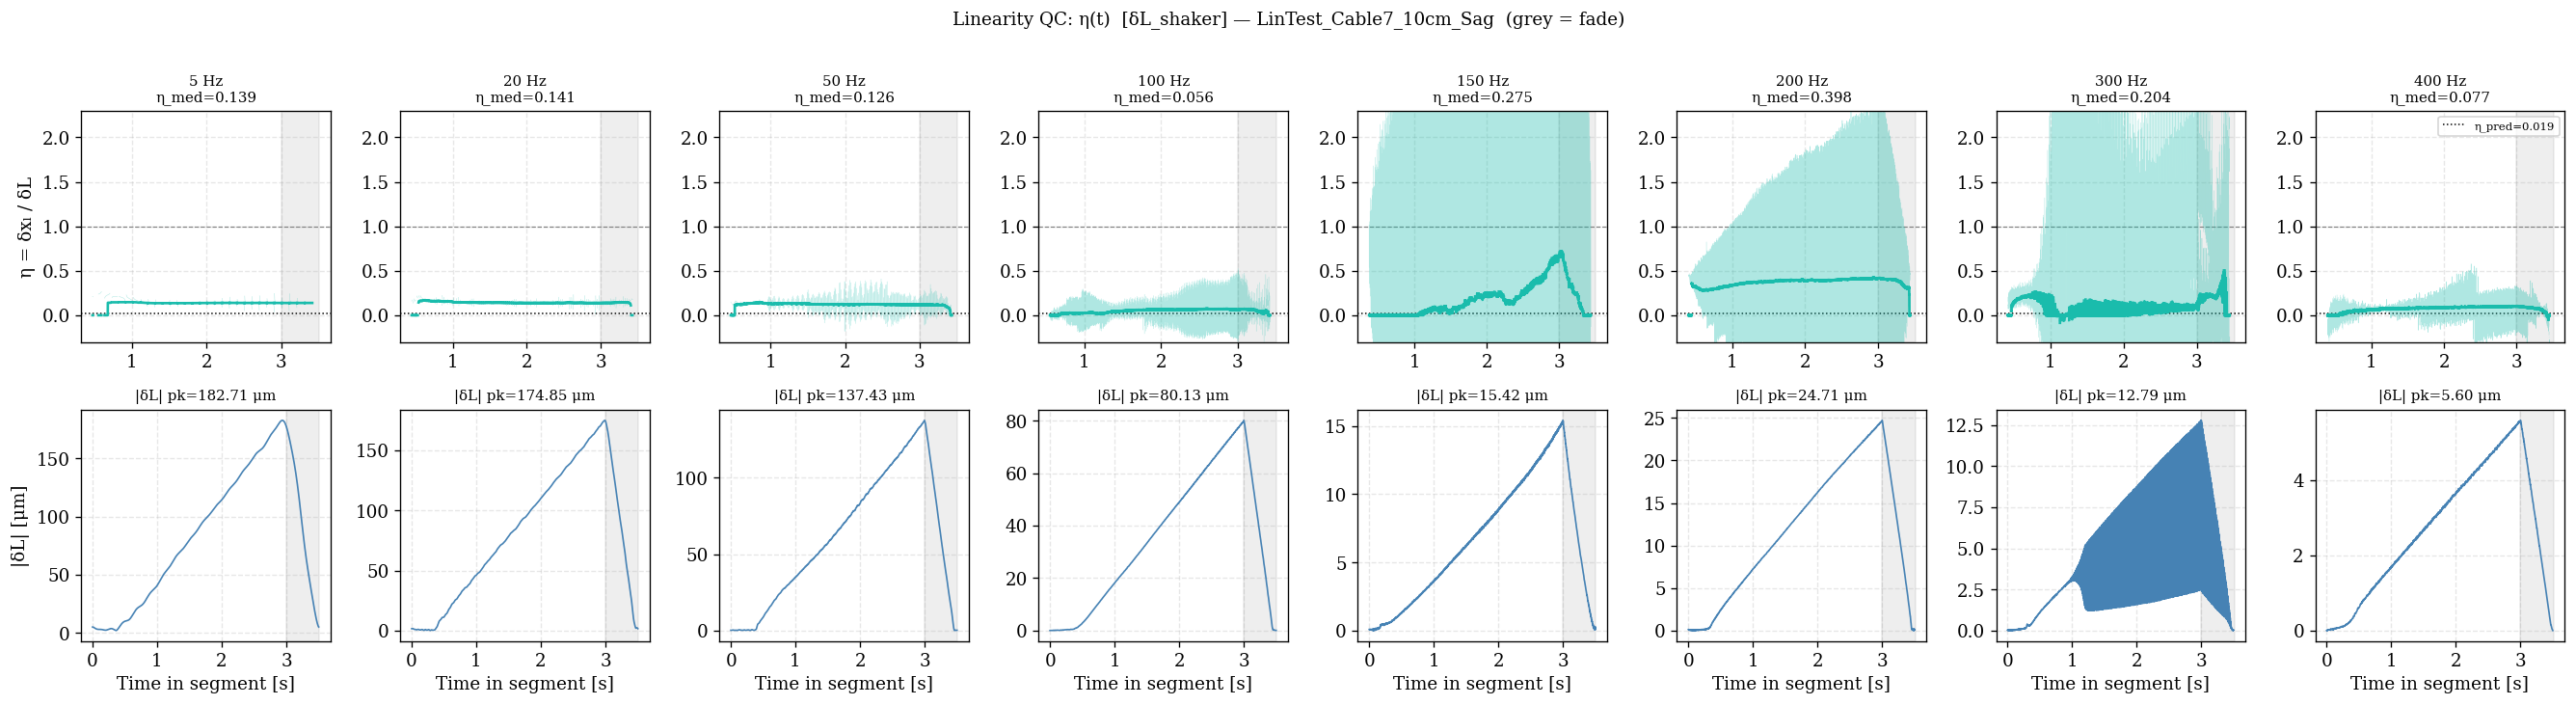

In [8]:
for cfg in DATASETS:
    plotting.plot_linearity_eta_time(
        cfg, cfg['lin_results'],
        smooth_cycles=5,
        ref='shaker',   # or 'ends'
    )


---
## Section 6  eta vs amplitude -- linearity check

**Left panel:** scatter of eta against |delta_L|, coloured by time within
the segment. A hysteresis loop indicates amplitude-dependent coupling.

**Right panel:** binned-median eta -- horizontal = linear coupling;
any slope = nonlinear.

Only the ramp portion (monotonically increasing amplitude) is used by default.


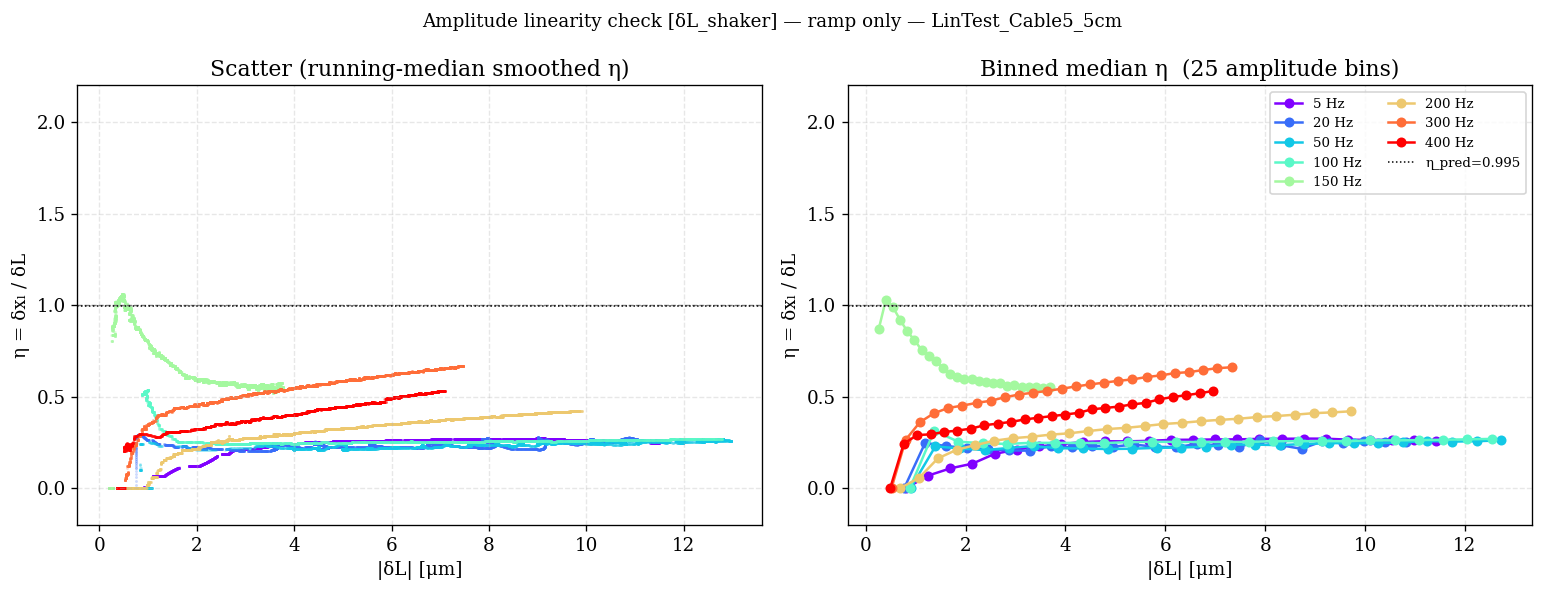

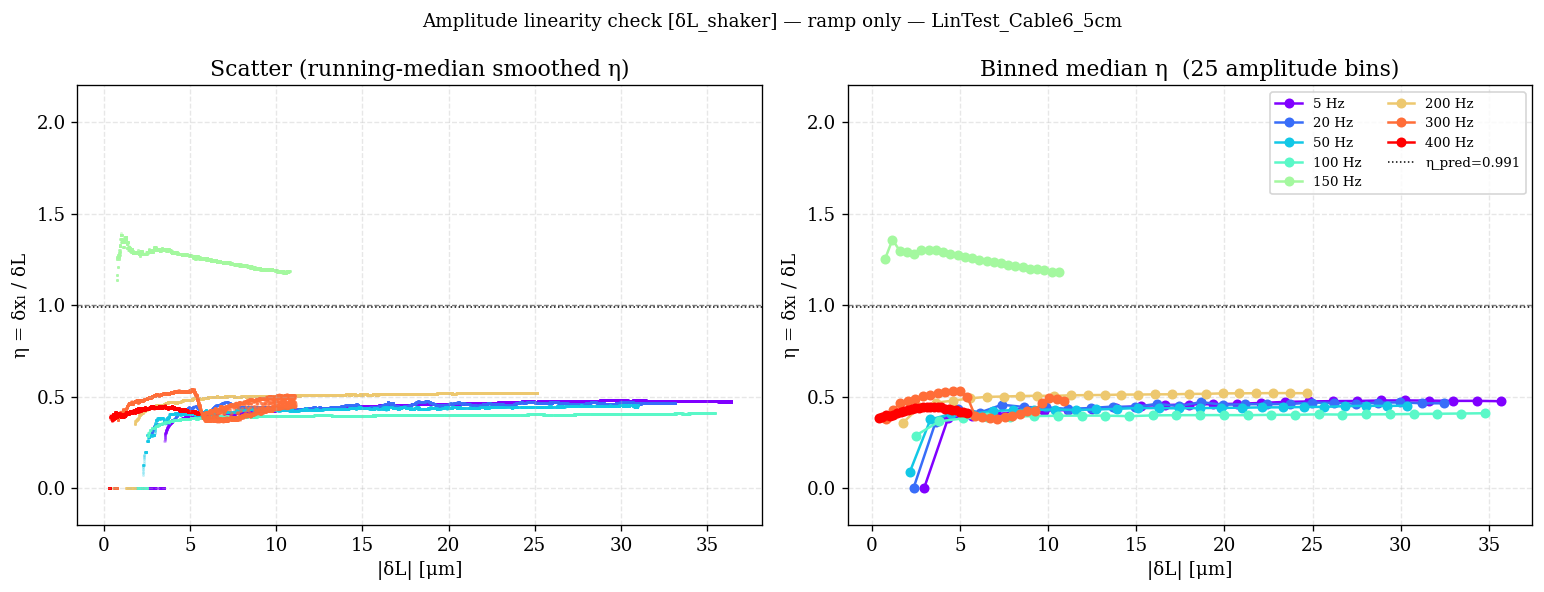

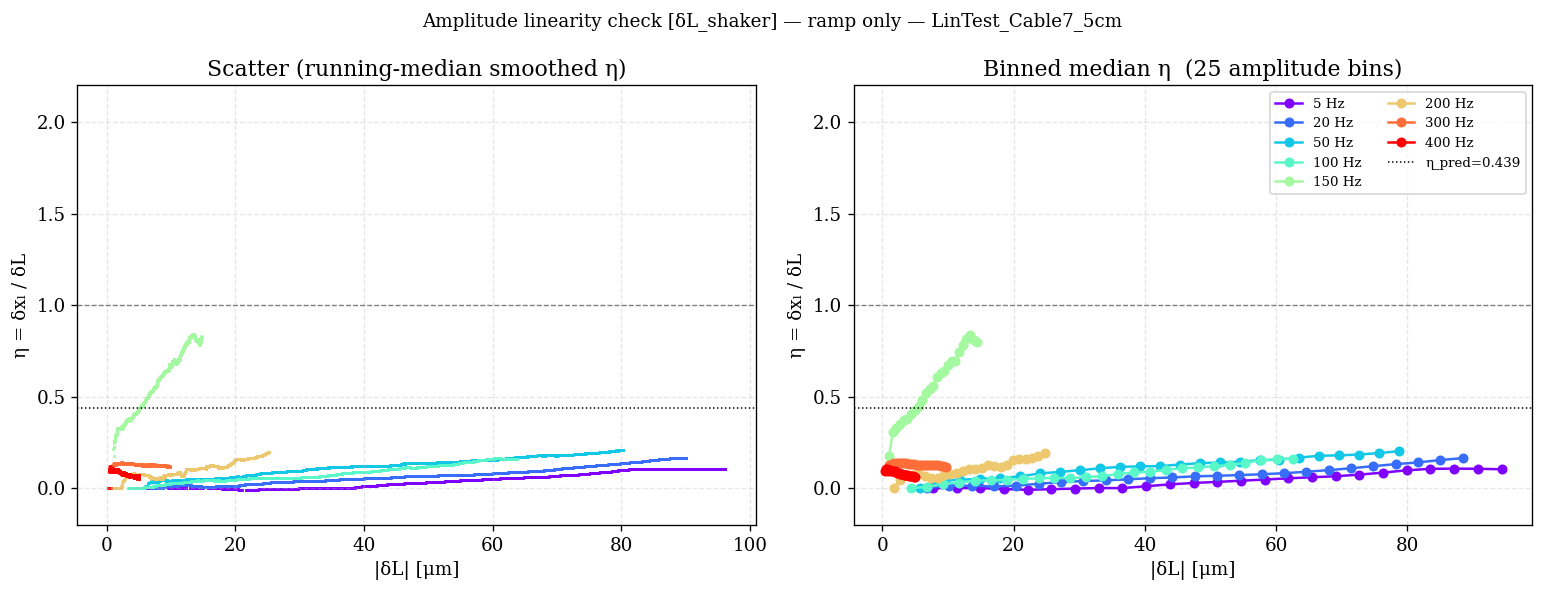

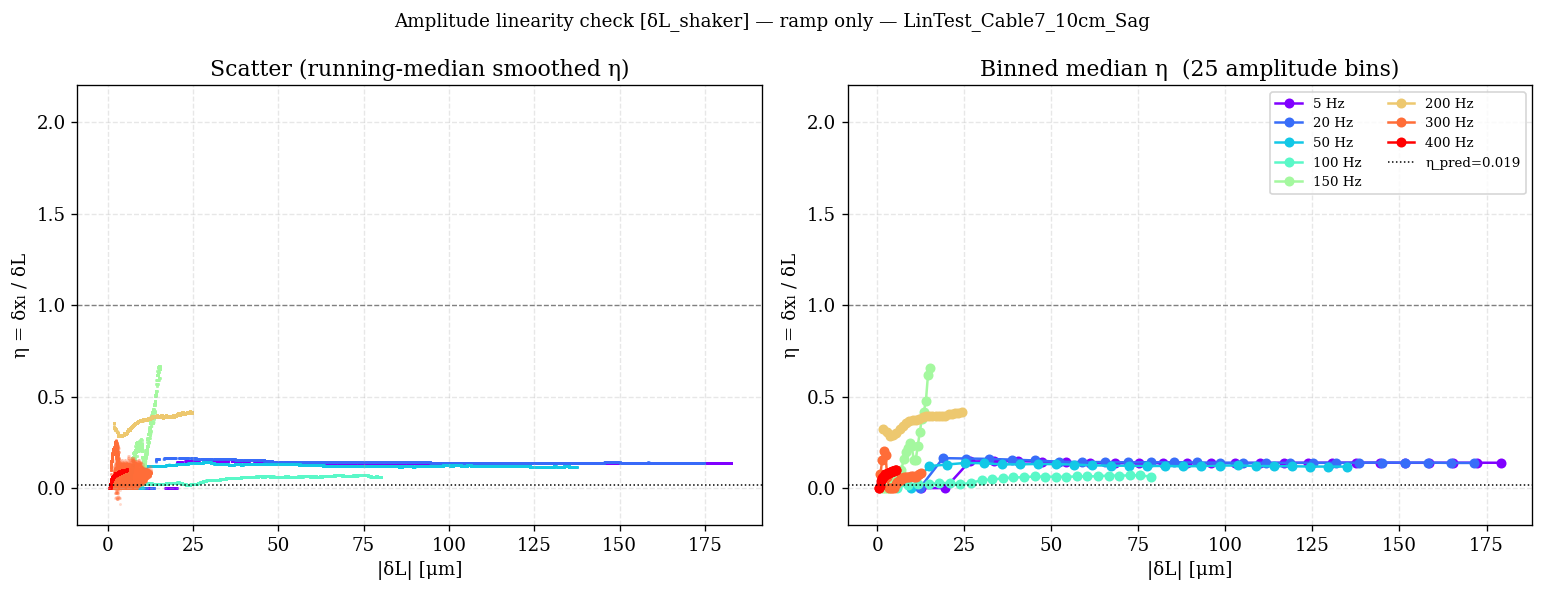

In [9]:
plotting.plot_linearity_eta_vs_amplitude(
    DATASETS,
    smooth_cycles=5,
    exclude_fade=True,   # set False to include the fade region
    n_bins=25,
    ref='shaker',
)


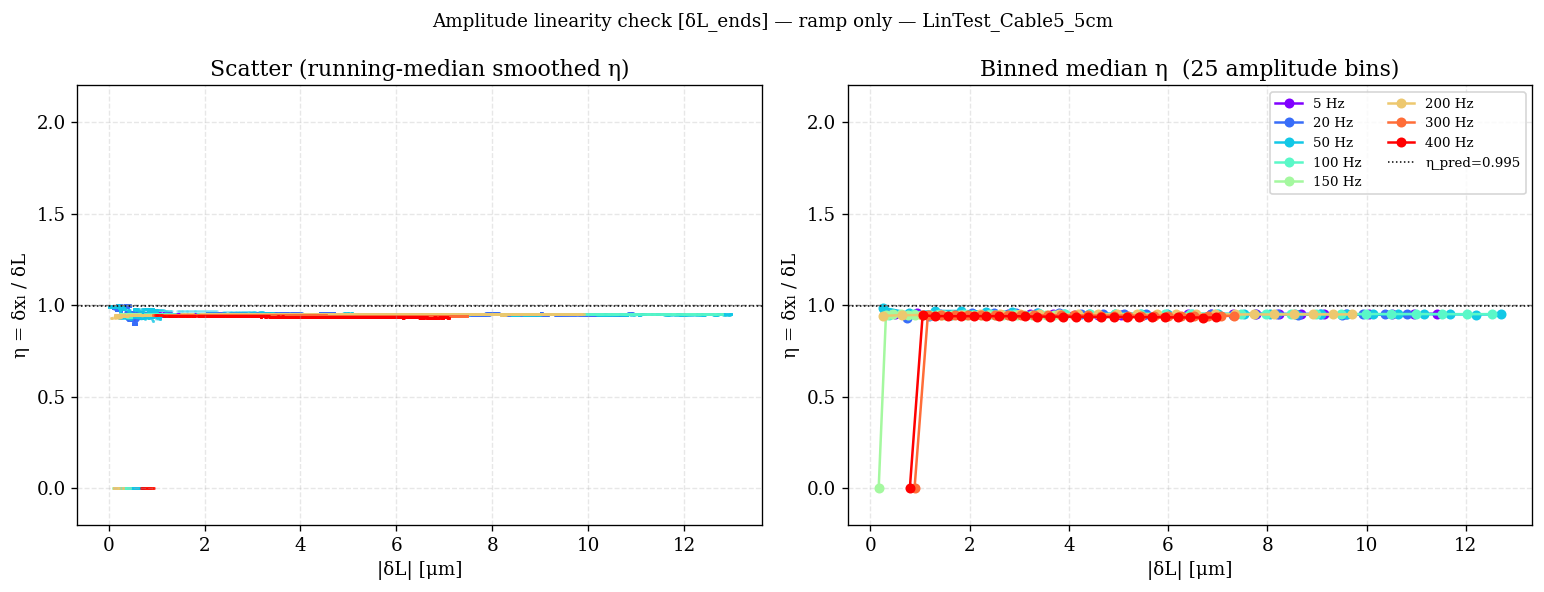

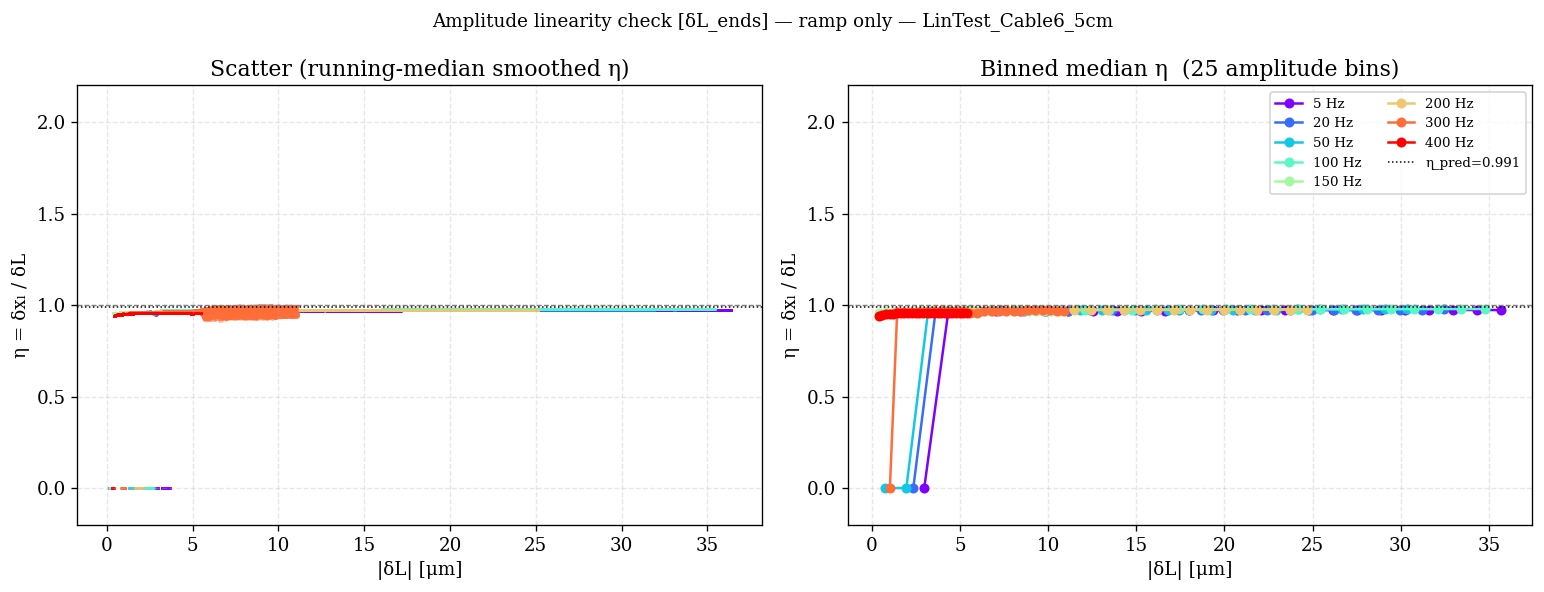

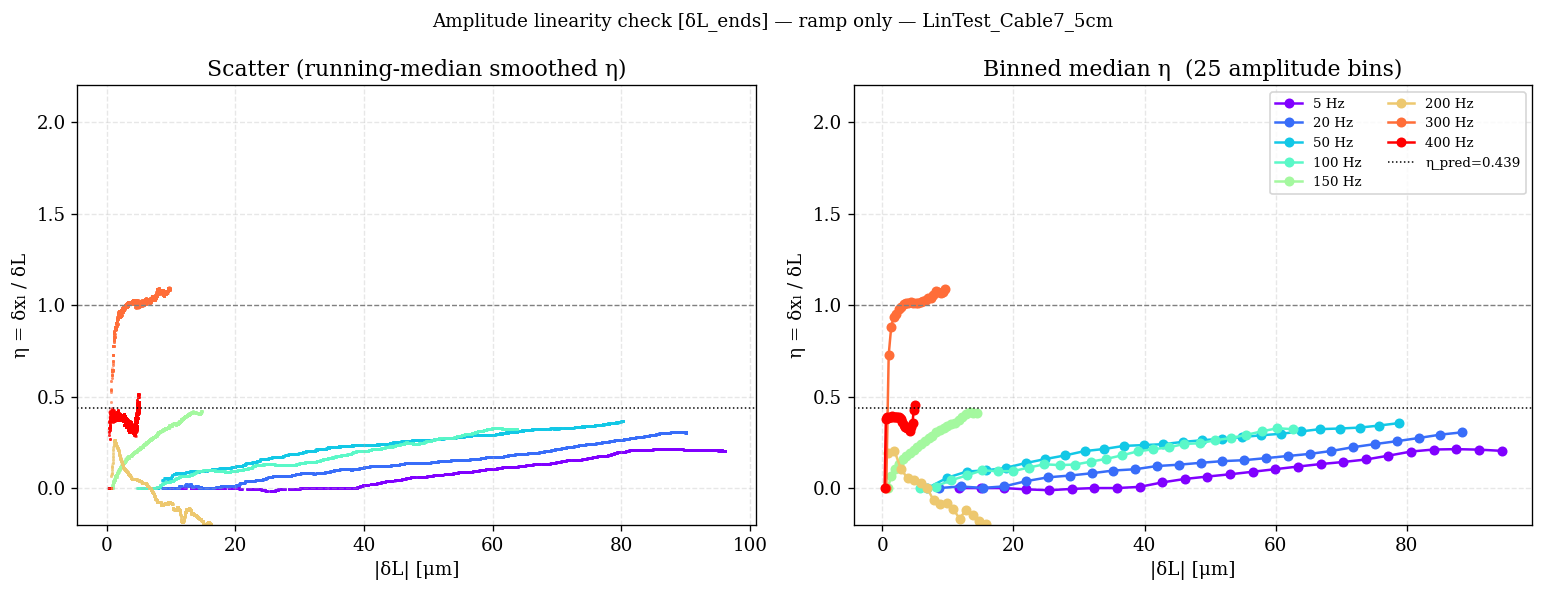

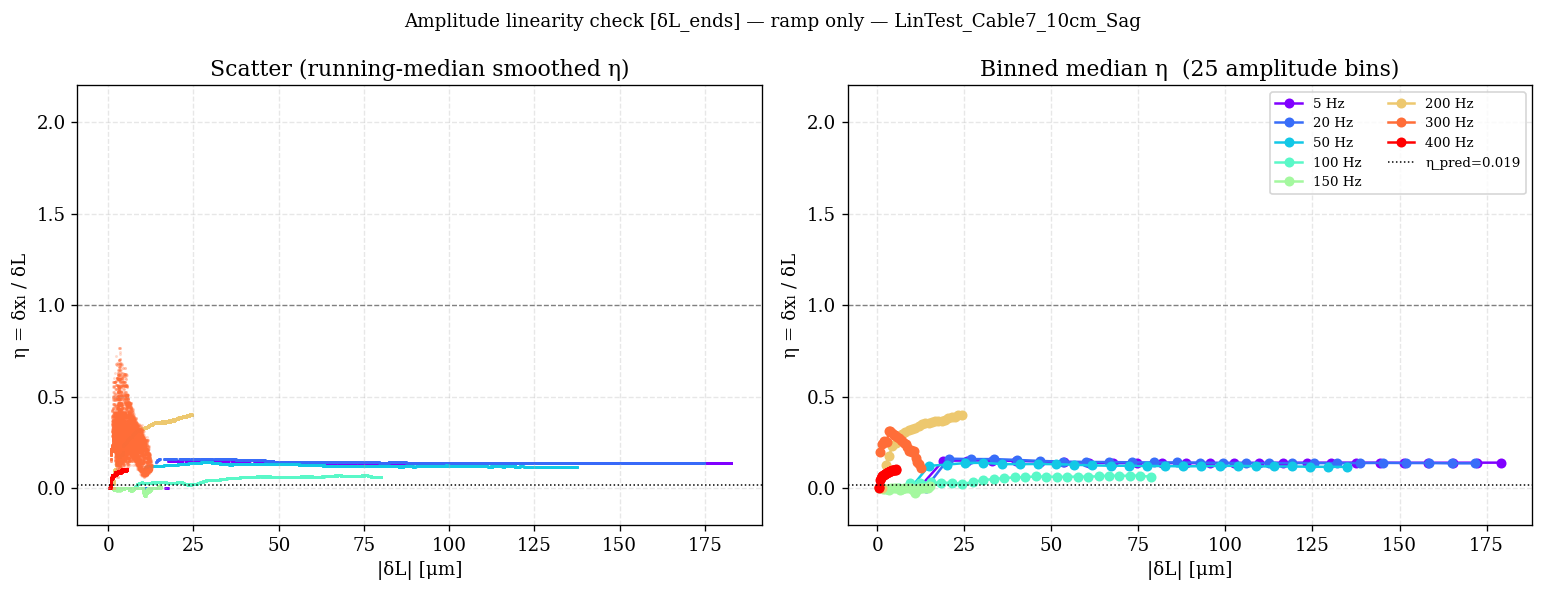

In [10]:
# Same with 'ends' reference (no shaker -- cable end-sensor elongation)
plotting.plot_linearity_eta_vs_amplitude(
    DATASETS,
    smooth_cycles=5,
    exclude_fade=True,
    n_bins=25,
    ref='ends',
)


---
## Section 7  Cross-cable comparison

All cables overlaid on one figure per target frequency.
Checks whether amplitude dependence is cable-specific or universal.
Dotted lines = individual eta_pred per cable.


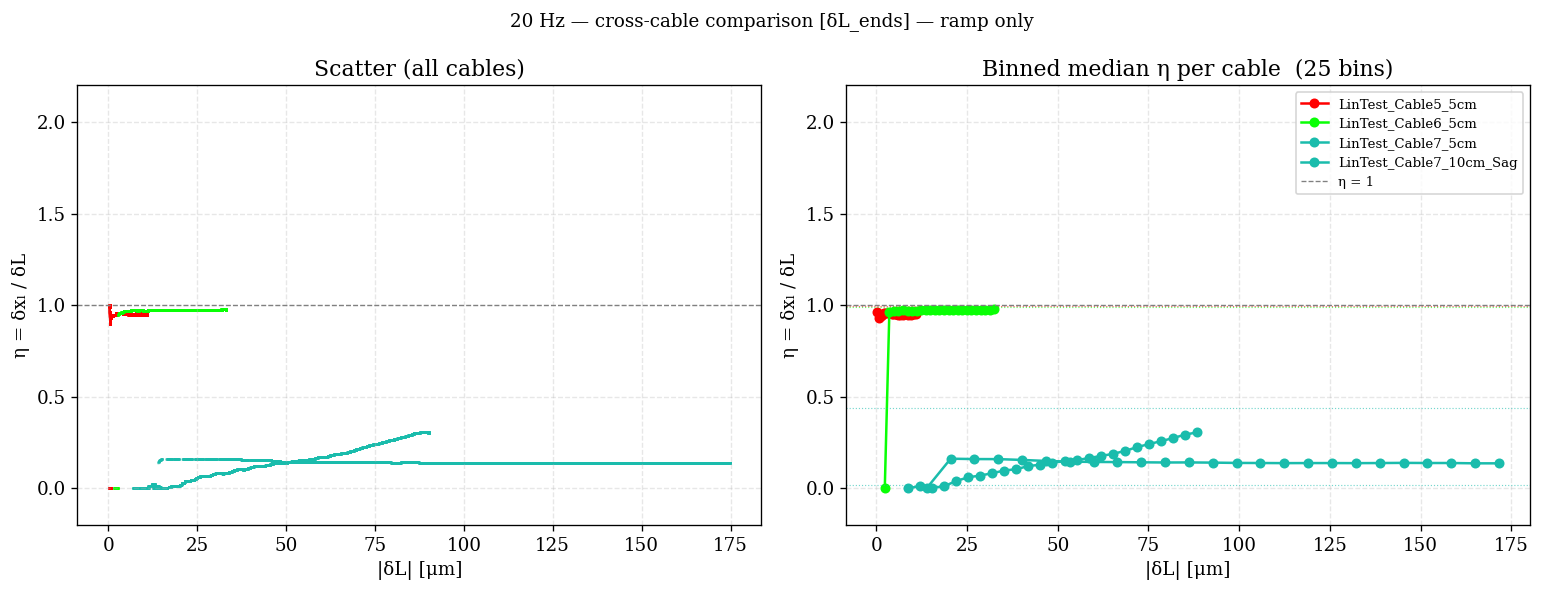

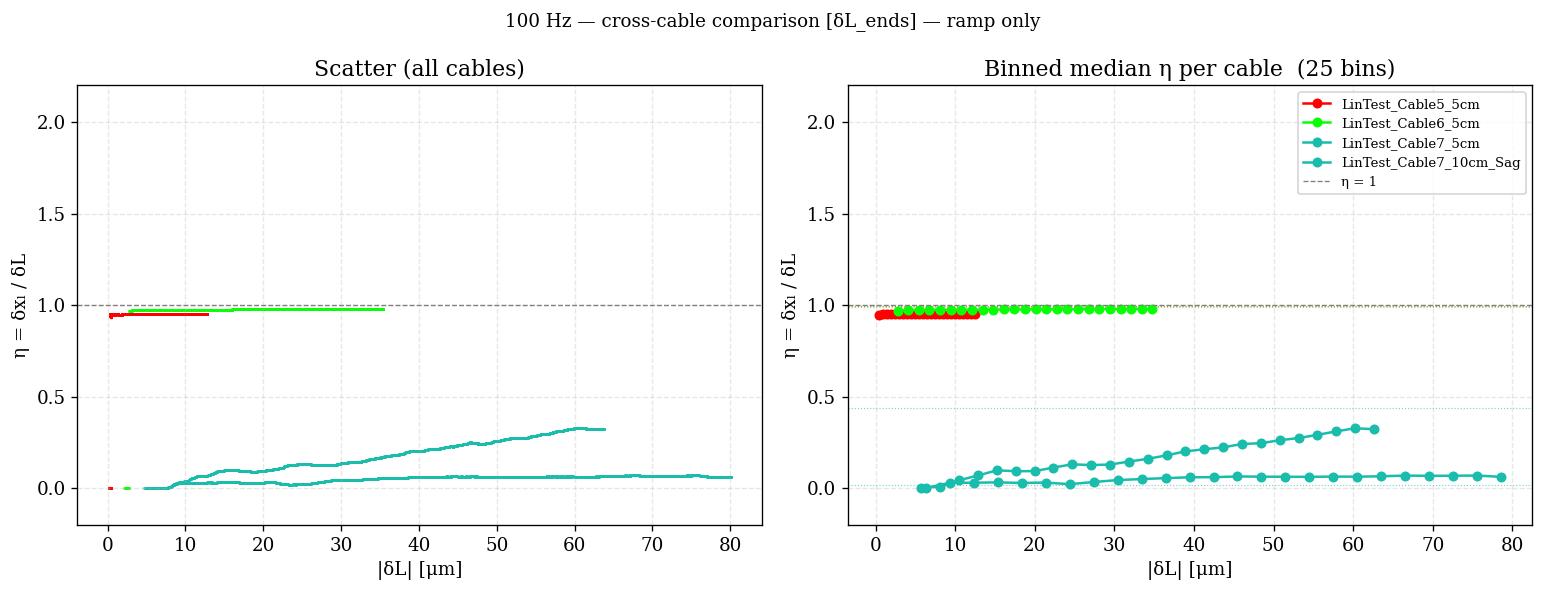

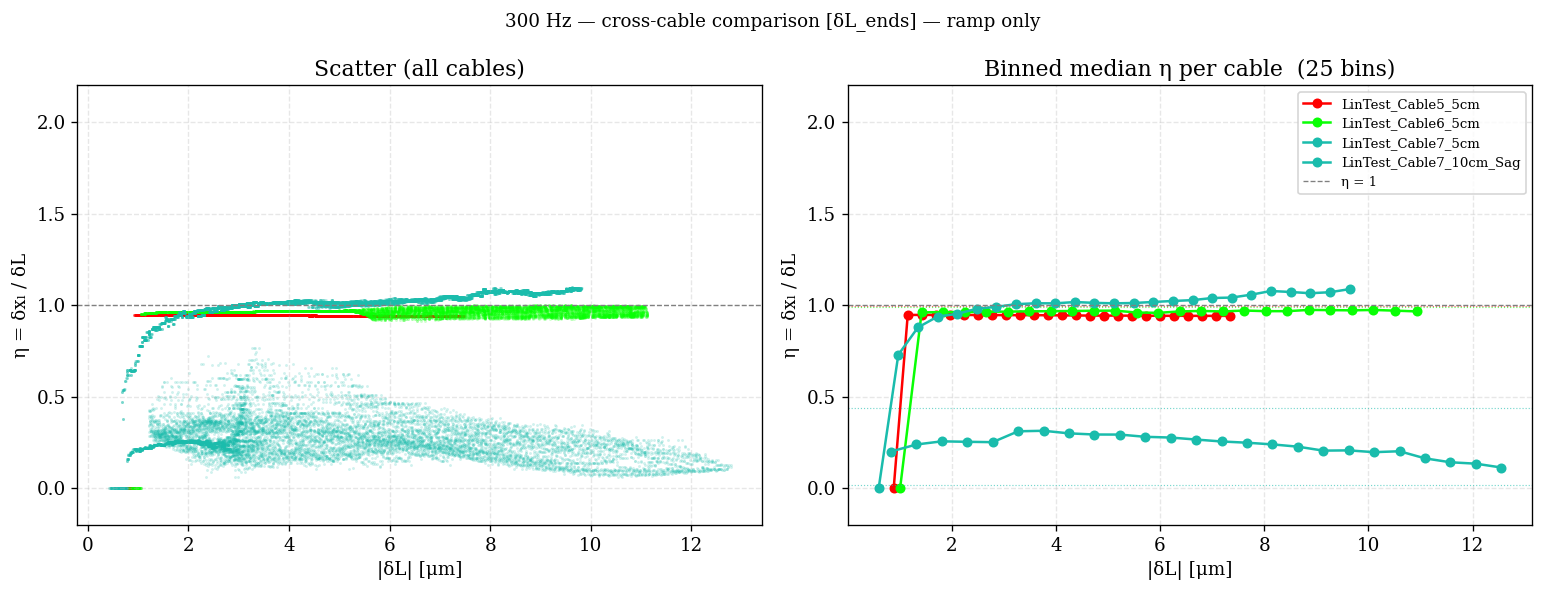

In [11]:
for f_compare in [20, 100, 300]:   # edit as needed
    plotting.plot_linearity_comparison(
        DATASETS, f_target=f_compare,
        smooth_cycles=5, exclude_fade=True,
        ref='ends', n_bins=25,
    )


---
## Section 8  Interactive QC dashboard

Controls:
- **Cable** -- pick dataset.
- **Frequency** -- any of the 8 linearity test frequencies.
- **View** -- `eta(t)`: time traces + amplitude envelope;
  `eta vs amplitude`: scatter + binned-median linearity check;
  `raw waveforms`: bandpassed vx/vy/vz space-time wavefields.
- **Reference** -- `shaker` or `ends`.
- **Smooth** -- running-median window in cycles of the target frequency.
- **Ramp only** -- exclude the 0.5 s fade at segment end.
- **Amp. bins** -- number of amplitude bins for the binned-median panel.


In [ ]:
widgets.linearity_dashboard(DATASETS, frequencies=config.LIN_FREQUENCIES)
